In [40]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib import ticker
import seaborn as sns
import matplotlib.image as mpimg

from const import *

plt.style.use('default') # 重置
params = {
    'font.family': 'serif',        # 衬线体 (Times New Roman 等)
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'], # 显式指定
    'mathtext.fontset': 'stix',    # 数学公式字体更像 LaTeX
    'axes.labelsize': 14,
    'font.size': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'axes.spines.top': False,      # 去掉顶部边框 (更简洁)
    'axes.spines.right': False,    # 去掉右侧边框
}
plt.rcParams.update(params)

In [44]:
mesh_data_file = np.load("tissue_mesh.npz")
neighbors = mesh_data_file['neighbors']
node_pos_np, triangles = mesh_data_file['vertices'], mesh_data_file['faces']
# node_pos_np[:, 1] = -node_pos_np[:, 1]  # 翻转y轴以匹配视觉习惯

v_min, v_max = -1.4, 0.9

使用"Y_sum-0.csv"作为初始的变形数据，来自Y_ekf-1，Y_ekf-4

In [41]:
Y_0 = np.loadtxt("Y_sum-0.csv", delimiter=",")
bg_0 = mpimg.imread("bg-0.png")
high_prob_0 = np.loadtxt("low_value_indices-0.csv", delimiter=",", dtype=int)

high_prob_mask_0 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_0[high_prob_0] = True

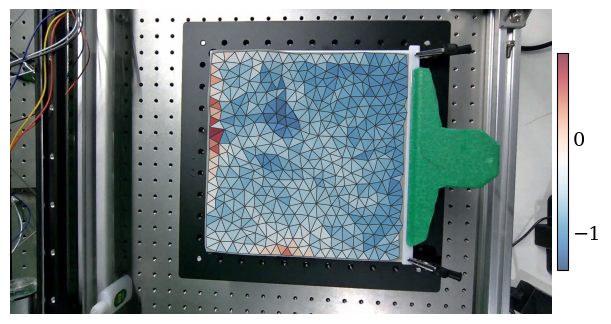

In [50]:
# cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.sqrt(np.diag(Y_0))
inform_normalized = np.log10(inform)
# v_min, v_max = inform_normalized.min(), inform_normalized.max()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_0, origin='upper')
im1 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=inform_normalized, shading='flat', 
                    edgecolors='#222222', linewidth=.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
# cbar1.mappable.set_clim(vmin=-, vmax=1)
cbar1.locator = ticker.MultipleLocator(1)
cbar1.update_ticks()

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_inform-0.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 95 high-probability triangles in init.


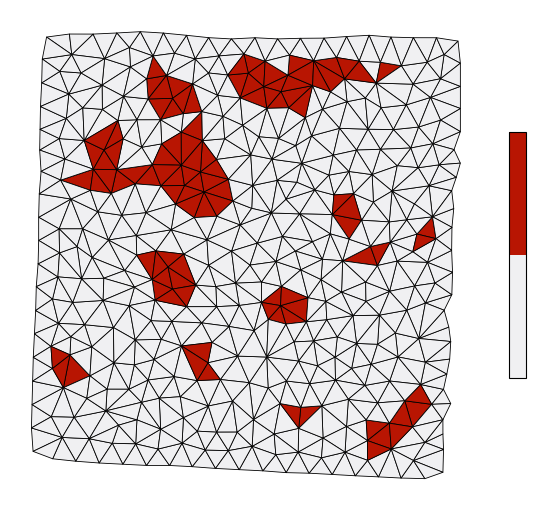

In [26]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_0.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_0.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_0.sum()} high-probability triangles in init.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9943

  Band PR-AUC: 0.9888

  Local Robust CNR: 2.1192

  Local FDR: 8.8677

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9962 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.9330 (Higher is better)

  [Field Metric 3] Robust CNR: 1.6175 (Higher is better)

  [Field Metric 4] FDR: 3.4391 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.3036

  [Seg Metric 2] IoU:        0.1789

  [Seg Metric 3] Precision:  0.1789

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.8776
  
  [Seg Metric 6] F1-score:   0.3036

---
UWS

First exploration

使用Y_ekf-5

In [52]:
mesh_1 = np.load("tissue_mesh-1-1.npz")
node_pos_np_1, triangles_1 = mesh_1['vertices'], mesh_1['faces']
# node_pos_np_1[:, 1] = -node_pos_np_1[:, 1]

In [53]:
Y_1_1 = np.loadtxt("Y_sum-1-1.csv", delimiter=",")
bg_1_1 = mpimg.imread("bg-1-1.png")
high_prob_uws_1 = np.loadtxt("low_value_indices-uws-1.csv", delimiter=",", dtype=int)

high_prob_mask_uws_1 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_uws_1[high_prob_uws_1] = True

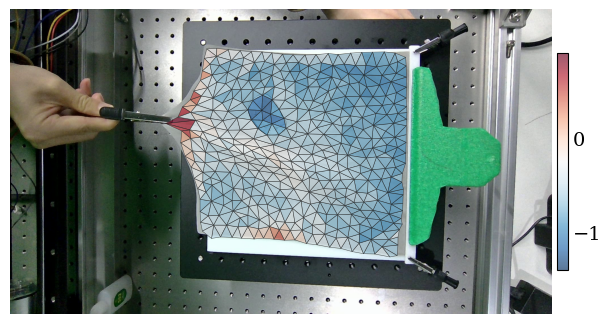

In [58]:
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.sqrt(np.diag(Y_1_1))
inform_normalized = np.log10(inform)
# v_min, v_max = inform_normalized.min(), inform_normalized.max()

# tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max))+1)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_1_1, origin='upper')
im1 = ax1.tripcolor(node_pos_np_1[:, 0], node_pos_np_1[:, 1], triangles_1, 
                    facecolors=inform_normalized, shading='flat', 
                    edgecolors='#222222', linewidth=.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)

# cbar1.set_ticks(tick_locs)
# cbar1.set_ticklabels([f"$10^{{ {int(loc):d} }}$" for loc in tick_locs])

plt.savefig(f"stiffness_inform-uws-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 58 high-probability triangles in UWS-1.


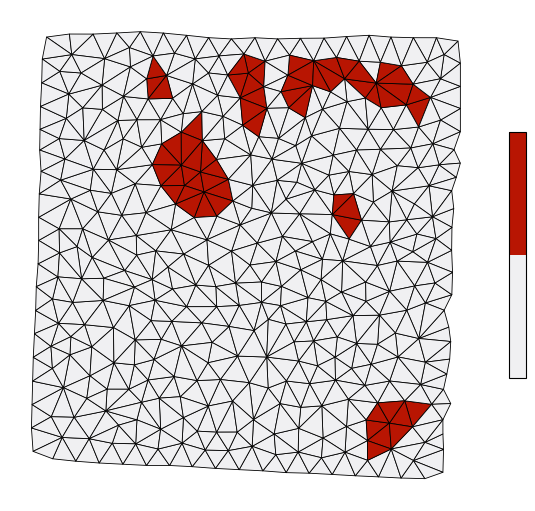

In [29]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_uws_1.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_uws_1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_uws_1.sum()} high-probability triangles in UWS-1.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9928

  Band PR-AUC: 0.9840

  Local Robust CNR: 1.6154

  Local FDR: 5.9888

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9744 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.7458 (Higher is better)

  [Field Metric 3] Robust CNR: 1.1507 (Higher is better)

  [Field Metric 4] FDR: 2.8505 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.4533

  [Seg Metric 2] IoU:        0.2931

  [Seg Metric 3] Precision:  0.2931

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.9356
  
  [Seg Metric 6] F1-score:   0.4533

Second Exploration

使用Y_ekf-6

In [60]:
mesh_2 = np.load("tissue_mesh-1-2&2-1.npz")
node_pos_np_2, triangles_2 = mesh_2['vertices'], mesh_2['faces']
# node_pos_np_2[:, 1] = -node_pos_np_2[:, 1]

In [62]:
Y_uws_2 = np.loadtxt("Y_sum-1-2.csv", delimiter=",")
bg_uws_2 = mpimg.imread("bg_1-2&2-1.png")
high_prob_uws_2 = np.loadtxt("low_value_indices-uws-2.csv", delimiter=",", dtype=int)

high_prob_mask_uws_2 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_uws_2[high_prob_uws_2] = True


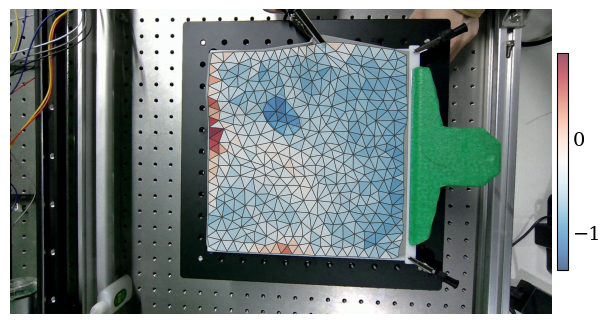

In [63]:
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.sqrt(np.diag(Y_uws_2))
inform_normalized = np.log10(inform)
# v_min, v_max = inform_normalized.min(), inform_normalized.max()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_uws_2, origin='upper')
im1 = ax1.tripcolor(node_pos_np_2[:, 0], node_pos_np_2[:, 1], triangles_2, 
                    facecolors=inform_normalized, shading='flat', 
                    edgecolors='#222222', linewidth=0.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)

plt.savefig(f"stiffness_inform-uws-2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 46 high-probability triangles in UWS-2.


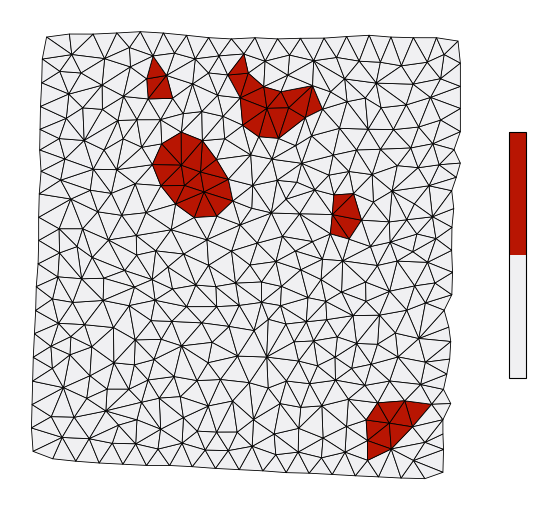

In [32]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_uws_2.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_uws_2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_uws_2.sum()} high-probability triangles in UWS-2.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9957

  Band PR-AUC: 0.9912

  Local Robust CNR: 1.8490

  Local FDR: 6.4862

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9917 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.9135 (Higher is better)

  [Field Metric 3] Robust CNR: 1.3395 (Higher is better)

  [Field Metric 4] FDR: 3.5572 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.5397

  [Seg Metric 2] IoU:        0.3696

  [Seg Metric 3] Precision:  0.3696

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.9545
  
  [Seg Metric 6] F1-score:   0.5397

---
SWS

First Exploration

使用Y_ekf-6

In [64]:
mesh_sws_1 = np.load("tissue_mesh-1-2&2-1.npz")
node_pos_np_sws_1, triangles_sws_1 = mesh_sws_1['vertices'], mesh_sws_1['faces']
# node_pos_np_sws_1[:, 1] = -node_pos_np_sws_1[:, 1]

In [65]:
Y_sws_1 = np.loadtxt("Y_sum-2-1.csv", delimiter=",")
bg_sws_1 = mpimg.imread("bg_1-2&2-1.png")
high_prob_sws_1 = np.loadtxt("low_value_indices-sws-1.csv", delimiter=",", dtype=int)

high_prob_mask_sws_1 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_sws_1[high_prob_sws_1] = True


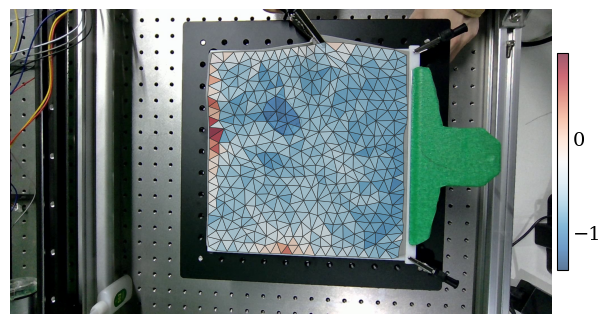

In [66]:
# cmap_custom = sns.color_palette("RdYlBu_r", as_cmap=True)
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.sqrt(np.diag(Y_sws_1))
inform_normalized = np.log10(inform)
# v_min, v_max = inform_normalized.min(), inform_normalized.max()

# tick_locs = np.arange(np.ceil(np.log10(v_min)), np.floor(np.log10(v_max))+1)
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_sws_1, origin='upper')
im1 = ax1.tripcolor(node_pos_np_sws_1[:, 0], node_pos_np_sws_1[:, 1], triangles_sws_1, 
                    facecolors=inform_normalized, shading='flat', 
                    edgecolors='#222222', linewidth=0.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)

plt.savefig(f"stiffness_inform-sws-1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 100 high-probability triangles in SWS-1.


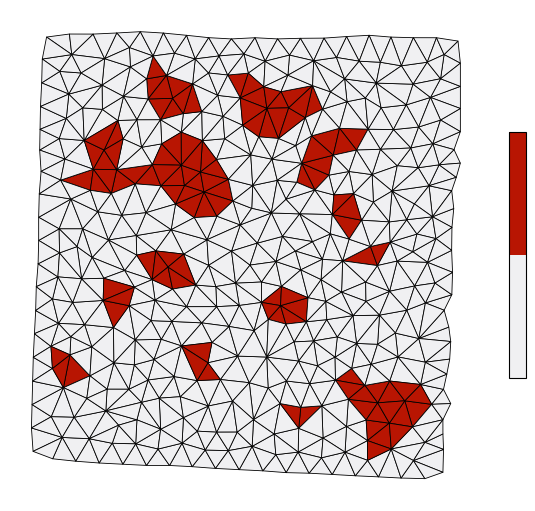

In [35]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_sws_1.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_sws_1.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_sws_1.sum()} high-probability triangles in SWS-1.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 0.9986

  Band PR-AUC: 0.9967

  Local Robust CNR: 2.4648

  Local FDR: 10.3844

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9996 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.9888 (Higher is better)

  [Field Metric 3] Robust CNR: 2.0395 (Higher is better)

  [Field Metric 4] FDR: 4.3550 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.2906

  [Seg Metric 2] IoU:        0.1700

  [Seg Metric 3] Precision:  0.1700

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.8697
  
  [Seg Metric 6] F1-score:   0.2906

Second Exploration

使用Y_ekf-7

In [68]:
mesh_sws_2 = np.load("tissue_mesh-2-2.npz")
node_pos_np_sws_2, triangles_sws_2 = mesh_sws_2['vertices'], mesh_sws_2['faces']
# node_pos_np_sws_2[:, 1] = -node_pos_np_sws_2[:, 1]

In [69]:
Y_sws_2 = np.loadtxt("Y_sum-2-2.csv", delimiter=",")
bg_sws_2 = mpimg.imread("bg-2-2.png")
high_prob_sws_2 = np.loadtxt("low_value_indices-sws-2.csv", delimiter=",", dtype=int)

high_prob_mask_sws_2 = np.zeros(triangles.shape[0], dtype=bool)
high_prob_mask_sws_2[high_prob_sws_2] = True

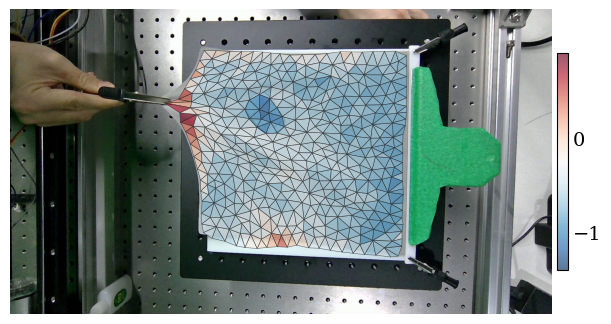

In [70]:
cmap_custom = sns.color_palette("RdBu_r", as_cmap=True)

inform = np.sqrt(np.diag(Y_sws_2))
inform_normalized = np.log10(inform)
# v_min, v_max = inform_normalized.min(), inform_normalized.max()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
ax1.imshow(bg_sws_2, origin='upper')
im1 = ax1.tripcolor(node_pos_np_sws_2[:, 0], node_pos_np_sws_2[:, 1], triangles_sws_2, 
                    facecolors=inform_normalized, shading='flat', 
                    edgecolors='#222222', linewidth=0.4, alpha=0.65, cmap=cmap_custom,    # 
                    vmin=v_min, vmax=v_max)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im1, ax=ax1, pad=0.01, shrink=0.8, aspect=20, fraction=0.02)
cbar1.ax.tick_params(length=0, labelsize=14)
cbar1.locator = ticker.MultipleLocator(1)

plt.savefig(f"stiffness_inform-sws-2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')

Detected 58 high-probability triangles in SWS-1.


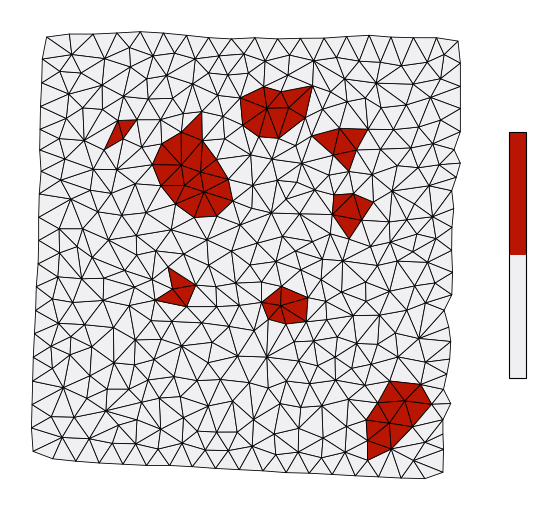

In [39]:
colors = ['#F0F0F2', '#B81502'] # E3F2FD 1F77B4 B81502
cmap_custom = ListedColormap(colors)

fig, ax1 = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im2 = ax1.tripcolor(node_pos_np[:, 0], node_pos_np[:, 1], triangles, 
                    facecolors=high_prob_mask_sws_2.astype(int), shading='flat', 
                    edgecolors='k', linewidth=0.6, cmap=cmap_custom, vmin=0, vmax=1)
# ax1.set_title('(b) Graph Cut Segmentation (Output)', pad=15)
ax1.set_aspect('equal')
ax1.axis('off')

# 自定义 Colorbar 的刻度
cbar1 = plt.colorbar(im2, ax=ax1, fraction=0.046, shrink=0.5, aspect=15)
cbar1.ax.tick_params(length=0)
cbar1.ax.set_yticklabels([])

plt.savefig(f"target_region_prob_sws_2.svg", transparent=True, format='svg', dpi=300, bbox_inches='tight')
print(f"Detected {high_prob_mask_sws_2.sum()} high-probability triangles in SWS-1.")

[Local Evaluation] (Using GT band as reference)

  Band ROC-AUC: 1.0000

  Band PR-AUC: 1.0000

  Local Robust CNR: 2.0403

  Local FDR: 8.5536

[Global Evaluation]

  [Field Metric 1] ROC-AUC: 0.9938 (Closer to 1.0 is better)

  [Field Metric 2] PR-AUC: 0.8845 (Higher is better)

  [Field Metric 3] Robust CNR: 1.4846 (Higher is better)

  [Field Metric 4] FDR: 3.2261 (Higher is better)

[Global Segmentation Evaluation]

  [Seg Metric 1] Dice:       0.4533

  [Seg Metric 2] IoU:        0.2931

  [Seg Metric 3] Precision:  0.2931

  [Seg Metric 4] Recall:     1.0000

  [Seg Metric 5] Specificity:0.9356
  
  [Seg Metric 6] F1-score:   0.4533